# 04 - Estimation du mouvement avec Lucas-Kanade

Dans cette étape, nous allons appliquer la méthode de Lucas-Kanade pour estimer le déplacement des points caractéristiques de l’objet entre deux images successives. Cette méthode permet de suivre des points d’intérêt d’une frame à la suivante en se basant sur les variations d’intensité.

Lucas-Kanade repose sur des hypothèses simples vues dans le cours :
- les déplacements entre deux images successives sont petits ;
- l’intensité lumineuse reste presque constante ;
- les pixels voisins ont un mouvement similaire localement.

Dans notre projet, nous allons suivre uniquement les points détectés sur l’objet, et non toute l’image.

## 1. Importation des bibliothèques

Nous importons les bibliothèques nécessaires. Nous essayons aussi d’utiliser les fonctions simples créées dans les étapes précédentes.

In [1]:
import os
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../")

try:
    from src.preprocessing import preprocess_image
    from src.detection import read_groundtruth, get_initial_bbox, detect_features_in_roi
    print("Fonctions importées depuis le dossier src.")
except ImportError:
    preprocess_image = None
    read_groundtruth = None
    get_initial_bbox = None
    detect_features_in_roi = None
    print("Import impossible : des versions simples seront utilisées dans le notebook si nécessaire.")

Fonctions importées depuis le dossier src.


## 2. Définition des chemins du dataset

Nous définissons les chemins du dataset, puis nous vérifions que les images et le fichier `groundtruth.txt` sont disponibles.

In [2]:
dataset_path = Path("../data/car/car-11")
img_path = dataset_path / "img"
groundtruth_path = dataset_path / "groundtruth.txt"

print("Chemin du dataset :", dataset_path)
print("Le dossier img existe :", img_path.exists())
print("Le fichier groundtruth.txt existe :", groundtruth_path.exists())

image_extensions = [".jpg", ".png", ".jpeg"]

if img_path.exists():
    image_files = sorted([
        file for file in img_path.iterdir()
        if file.suffix.lower() in image_extensions
    ])
else:
    image_files = []
    print("Attention : le dossier img est introuvable.")

print("Nombre total d'images :", len(image_files))
print("Cinq premières images :")
for image_file in image_files[:5]:
    print("-", image_file.name)

Chemin du dataset : ..\data\car\car-11
Le dossier img existe : True
Le fichier groundtruth.txt existe : True
Nombre total d'images : 1661
Cinq premières images :
- 00000001.jpg
- 00000002.jpg
- 00000003.jpg
- 00000004.jpg
- 00000005.jpg


## 3. Chargement de deux frames successives

Nous chargeons la frame 0 et la frame 1. Ces deux images successives vont nous permettre d’appliquer Lucas-Kanade sur un cas simple.

Frame 0 chargée : (720, 1280, 3)
Frame 1 chargée : (720, 1280, 3)


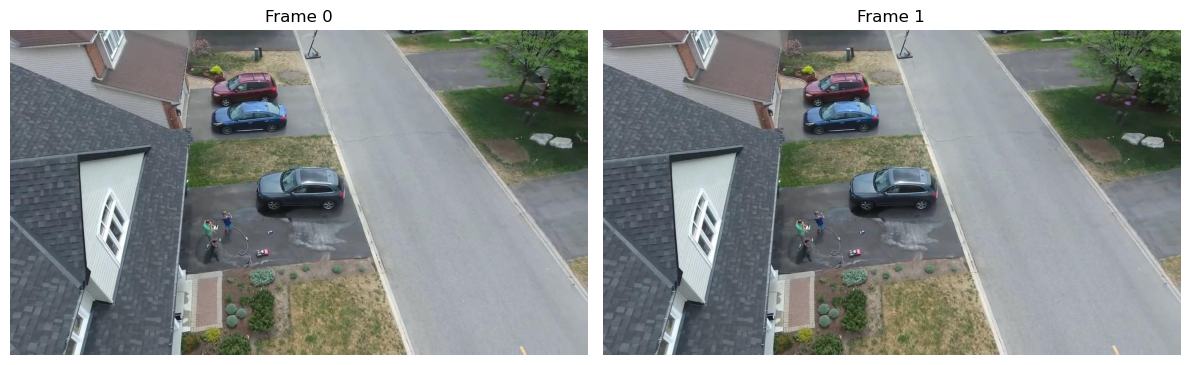

In [3]:
frame0_bgr = None
frame1_bgr = None

if len(image_files) >= 2:
    frame0_bgr = cv2.imread(str(image_files[0]))
    frame1_bgr = cv2.imread(str(image_files[1]))

    if frame0_bgr is not None and frame1_bgr is not None:
        print("Frame 0 chargée :", frame0_bgr.shape)
        print("Frame 1 chargée :", frame1_bgr.shape)

        frame0_rgb = cv2.cvtColor(frame0_bgr, cv2.COLOR_BGR2RGB)
        frame1_rgb = cv2.cvtColor(frame1_bgr, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(frame0_rgb)
        axes[0].set_title("Frame 0")
        axes[0].axis("off")

        axes[1].imshow(frame1_rgb)
        axes[1].set_title("Frame 1")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("Une des deux frames n'a pas pu être chargée.")
else:
    print("Il faut au moins deux images pour appliquer Lucas-Kanade.")

Nous commençons par deux images successives afin de comprendre le principe de Lucas-Kanade sur un cas simple.

## 4. Prétraitement des deux frames

Nous appliquons le même prétraitement que dans l’étape 02. Les images d’entrée de Lucas-Kanade doivent être en niveaux de gris.

Type frame 0 prétraitée : uint8
Type frame 1 prétraitée : uint8


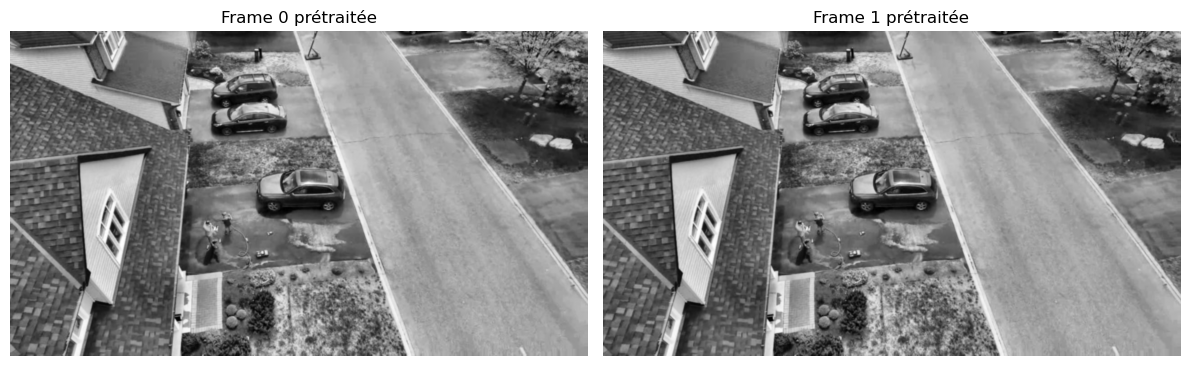

In [4]:
if preprocess_image is None:
    def preprocess_image(image_bgr):
        gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        preprocessed = cv2.GaussianBlur(enhanced, (5, 5), 0)
        return preprocessed

    print("Version simple de preprocess_image définie dans le notebook.")

prev_gray = None
next_gray = None

if frame0_bgr is not None and frame1_bgr is not None:
    prev_gray = preprocess_image(frame0_bgr)
    next_gray = preprocess_image(frame1_bgr)

    print("Type frame 0 prétraitée :", prev_gray.dtype)
    print("Type frame 1 prétraitée :", next_gray.dtype)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(prev_gray, cmap="gray")
    axes[0].set_title("Frame 0 prétraitée")
    axes[0].axis("off")

    axes[1].imshow(next_gray, cmap="gray")
    axes[1].set_title("Frame 1 prétraitée")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Impossible de prétraiter les frames car elles ne sont pas chargées.")

Les images prétraitées sont utilisées comme entrée de Lucas-Kanade. Nous travaillons en niveaux de gris car le flot optique se base sur les variations d’intensité.

## 5. Initialisation des points caractéristiques de l’objet

Nous lisons la première bounding box du fichier `groundtruth.txt`, puis nous détectons les points caractéristiques dans la région de l’objet.

Bounding box initiale : (543, 305, 202, 91)
Nombre de points détectés : 80


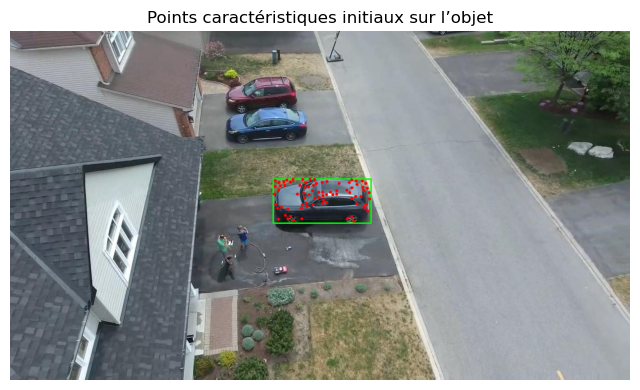

In [5]:
groundtruth = pd.DataFrame(columns=["x", "y", "w", "h"])
initial_bbox = None
points = None

if read_groundtruth is not None:
    groundtruth = read_groundtruth(groundtruth_path)
elif groundtruth_path.exists() and groundtruth_path.stat().st_size > 0:
    groundtruth = pd.read_csv(groundtruth_path, header=None, sep=r"[,\s]+", engine="python")
    groundtruth = groundtruth.iloc[:, :4]
    groundtruth.columns = ["x", "y", "w", "h"]
    groundtruth = groundtruth.astype(int)

if len(groundtruth) > 0:
    if get_initial_bbox is not None:
        initial_bbox = get_initial_bbox(groundtruth)
    else:
        x, y, w, h = groundtruth.iloc[0]
        initial_bbox = (int(x), int(y), int(w), int(h))

    print("Bounding box initiale :", initial_bbox)
else:
    print("Aucune bounding box n'a été trouvée.")

if prev_gray is not None and initial_bbox is not None:
    x, y, w, h = initial_bbox
    roi_gray = prev_gray[y:y + h, x:x + w]

    points = cv2.goodFeaturesToTrack(
        roi_gray,
        maxCorners=80,
        qualityLevel=0.01,
        minDistance=7,
        blockSize=7
    )

    if points is not None:
        points = points.astype(np.float32)
        points[:, 0, 0] += x
        points[:, 0, 1] += y
        print("Nombre de points détectés :", len(points))
    else:
        print("Aucun point n'a été détecté dans la ROI.")

if frame0_bgr is not None and initial_bbox is not None:
    x, y, w, h = initial_bbox
    image_points = frame0_bgr.copy()
    cv2.rectangle(image_points, (x, y), (x + w, y + h), (0, 255, 0), 2)

    if points is not None:
        for point in points:
            px, py = point.ravel().astype(int)
            cv2.circle(image_points, (px, py), 3, (0, 0, 255), -1)

    image_points_rgb = cv2.cvtColor(image_points, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 5))
    plt.imshow(image_points_rgb)
    plt.title("Points caractéristiques initiaux sur l’objet")
    plt.axis("off")
    plt.show()

Ces points représentent les détails de l’objet que Lucas-Kanade va essayer de retrouver dans l’image suivante.

## 6. Application de Lucas-Kanade entre deux frames

Nous appliquons Lucas-Kanade entre la frame 0 et la frame 1. Ensuite, nous gardons uniquement les points suivis avec succès.

In [6]:
good_old = None
good_new = None

lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
)

if prev_gray is not None and next_gray is not None and points is not None:
    new_points, status, error = cv2.calcOpticalFlowPyrLK(
        prev_gray,
        next_gray,
        points,
        None,
        **lk_params
    )

    if new_points is not None and status is not None:
        good_mask = status.ravel() == 1
        good_old = points[good_mask].reshape(-1, 2)
        good_new = new_points[good_mask].reshape(-1, 2)

        print("Nombre de points initiaux :", len(points))
        print("Nombre de points suivis avec succès :", len(good_new))
        print("Nombre de points perdus :", len(points) - len(good_new))
    else:
        print("Lucas-Kanade n'a pas retourné de points suivis.")
else:
    print("Impossible d'appliquer Lucas-Kanade car une donnée manque.")

Nombre de points initiaux : 80
Nombre de points suivis avec succès : 80
Nombre de points perdus : 0


Lucas-Kanade estime la nouvelle position de chaque point dans la frame suivante. Certains points peuvent être perdus si leur apparence change ou s’ils deviennent difficiles à suivre.

## 7. Visualisation des vecteurs de mouvement

Nous dessinons les anciens points, les nouveaux points et les lignes qui représentent le déplacement estimé entre les deux frames.

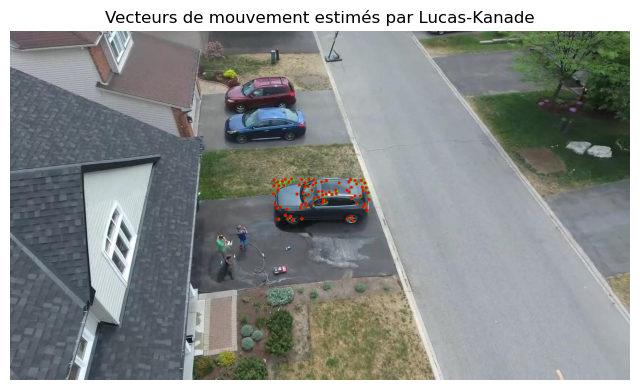

In [7]:
if frame1_bgr is not None and good_old is not None and good_new is not None:
    motion_image = frame1_bgr.copy()

    for old_point, new_point in zip(good_old, good_new):
        old_x, old_y = old_point.astype(int)
        new_x, new_y = new_point.astype(int)

        cv2.line(motion_image, (old_x, old_y), (new_x, new_y), (255, 0, 0), 2)
        cv2.circle(motion_image, (old_x, old_y), 3, (0, 255, 0), -1)
        cv2.circle(motion_image, (new_x, new_y), 3, (0, 0, 255), -1)

    motion_image_rgb = cv2.cvtColor(motion_image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 5))
    plt.imshow(motion_image_rgb)
    plt.title("Vecteurs de mouvement estimés par Lucas-Kanade")
    plt.axis("off")
    plt.show()
else:
    print("Impossible d'afficher les vecteurs de mouvement.")

Les lignes représentent le déplacement estimé des points entre deux frames successives. Si les vecteurs sont cohérents et orientés dans une direction similaire, cela indique que le suivi de l’objet fonctionne correctement.

## 8. Calcul du déplacement moyen entre deux frames

Nous calculons seulement un déplacement moyen entre la frame 0 et la frame 1. Ce n’est pas encore une analyse complète de vitesse ou de direction.

In [8]:
mean_dx = None
mean_dy = None

if good_old is not None and good_new is not None and len(good_old) > 0:
    dx = good_new[:, 0] - good_old[:, 0]
    dy = good_new[:, 1] - good_old[:, 1]

    mean_dx = np.mean(dx)
    mean_dy = np.mean(dy)

    print("Déplacement moyen en x :", mean_dx)
    print("Déplacement moyen en y :", mean_dy)
else:
    print("Impossible de calculer le déplacement moyen car aucun point n'a été suivi.")

Déplacement moyen en x : -0.6401421
Déplacement moyen en y : -0.03297348


Le déplacement moyen donne une première estimation du mouvement global de l’objet entre deux images successives. Cette idée sera utilisée plus tard pour extraire la trajectoire complète.

## 9. Test de Lucas-Kanade sur plusieurs frames

Nous testons maintenant Lucas-Kanade sur un petit nombre de frames, par exemple les 30 premières. Le but est seulement de vérifier si les points restent suivis sur plusieurs images.

Frame 1 : 80 points suivis
Frame 2 : 80 points suivis
Frame 3 : 80 points suivis
Frame 4 : 80 points suivis
Frame 5 : 80 points suivis
Frame 6 : 80 points suivis
Frame 7 : 80 points suivis
Frame 8 : 80 points suivis
Frame 9 : 80 points suivis
Frame 10 : 80 points suivis
Frame 11 : 80 points suivis
Frame 12 : 80 points suivis
Frame 13 : 80 points suivis
Frame 14 : 80 points suivis
Frame 15 : 80 points suivis
Frame 16 : 80 points suivis
Frame 17 : 80 points suivis
Frame 18 : 80 points suivis
Frame 19 : 80 points suivis
Frame 20 : 80 points suivis
Frame 21 : 80 points suivis
Frame 22 : 80 points suivis
Frame 23 : 80 points suivis
Frame 24 : 80 points suivis
Frame 25 : 80 points suivis
Frame 26 : 80 points suivis
Frame 27 : 80 points suivis
Frame 28 : 80 points suivis
Frame 29 : 80 points suivis


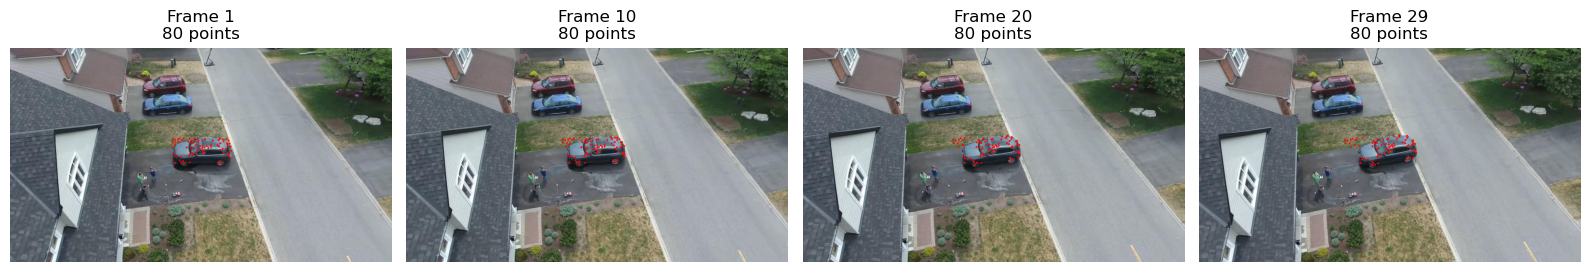

In [9]:
max_frames = min(30, len(image_files))
tracked_examples = []

if points is not None and prev_gray is not None and max_frames >= 2:
    current_points = points.copy().astype(np.float32)
    previous_gray = prev_gray.copy()
    display_indices = sorted(set([1, max_frames // 3, 2 * max_frames // 3, max_frames - 1]))

    for frame_index in range(1, max_frames):
        current_image_bgr = cv2.imread(str(image_files[frame_index]))

        if current_image_bgr is None:
            print(f"Frame {frame_index} : image non chargée")
            break

        current_gray = preprocess_image(current_image_bgr)
        new_points, status, error = cv2.calcOpticalFlowPyrLK(
            previous_gray,
            current_gray,
            current_points,
            None,
            **lk_params
        )

        if new_points is None or status is None:
            print(f"Frame {frame_index} : aucun point suivi")
            break

        good_mask = status.ravel() == 1
        tracked_points = new_points[good_mask].reshape(-1, 2)

        print(f"Frame {frame_index} : {len(tracked_points)} points suivis")

        if len(tracked_points) == 0:
            break

        if frame_index in display_indices:
            image_display = current_image_bgr.copy()
            for point in tracked_points:
                px, py = point.astype(int)
                cv2.circle(image_display, (px, py), 3, (0, 0, 255), -1)
            tracked_examples.append((frame_index, len(tracked_points), image_display))

        current_points = tracked_points.reshape(-1, 1, 2).astype(np.float32)
        previous_gray = current_gray

    if len(tracked_examples) > 0:
        fig, axes = plt.subplots(1, len(tracked_examples), figsize=(16, 4))
        if len(tracked_examples) == 1:
            axes = [axes]

        for axis, (frame_index, count, image_display) in zip(axes, tracked_examples):
            image_display_rgb = cv2.cvtColor(image_display, cv2.COLOR_BGR2RGB)
            axis.imshow(image_display_rgb)
            axis.set_title(f"Frame {frame_index}\n{count} points")
            axis.axis("off")

        plt.tight_layout()
        plt.show()
else:
    print("Impossible de tester plusieurs frames car les points initiaux manquent.")

Ce test nous permet de vérifier si les points caractéristiques restent stables sur plusieurs frames. Si le nombre de points diminue fortement, cela peut indiquer une perte de suivi, une occlusion ou un changement important de l’apparence de l’objet.

## 10. Création d’une fonction simple Lucas-Kanade

Nous regroupons maintenant l’application de Lucas-Kanade dans une fonction simple. Elle retourne seulement les anciens et les nouveaux points suivis avec succès.

In [10]:
def compute_lucas_kanade(prev_gray, next_gray, points):
    """
    Applique Lucas-Kanade entre deux images successives.

    Entrées :
    - prev_gray : image précédente prétraitée
    - next_gray : image suivante prétraitée
    - points : points à suivre

    Sorties :
    - good_old : anciens points suivis avec succès
    - good_new : nouveaux points suivis avec succès
    """
    if points is None or len(points) == 0:
        return None, None

    lk_params = dict(
        winSize=(15, 15),
        maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )

    new_points, status, error = cv2.calcOpticalFlowPyrLK(
        prev_gray,
        next_gray,
        points,
        None,
        **lk_params
    )

    if new_points is None or status is None:
        return None, None

    good_mask = status.ravel() == 1

    if not np.any(good_mask):
        return None, None

    good_old = points[good_mask].reshape(-1, 2)
    good_new = new_points[good_mask].reshape(-1, 2)

    return good_old, good_new

Nous testons la fonction sur la frame 0 et la frame 1 pour vérifier qu’elle retourne bien des points suivis.

In [11]:
test_good_old, test_good_new = compute_lucas_kanade(prev_gray, next_gray, points)

if test_good_old is not None and test_good_new is not None:
    print("Nombre de points suivis par la fonction :", len(test_good_new))
else:
    print("La fonction n'a pas retourné de points suivis.")

Nombre de points suivis par la fonction : 80


## 11. Conclusion de l’étape Lucas-Kanade

Dans cette étape, nous avons appliqué la méthode de Lucas-Kanade pour suivre les points caractéristiques de l’objet entre deux images successives. Nous avons visualisé les vecteurs de mouvement et calculé un déplacement moyen simple. Ce résultat montre comment les points de l’objet se déplacent d’une frame à l’autre. Dans l’étape suivante, nous utiliserons ces déplacements pour extraire la trajectoire globale de l’objet.

Nous nous arrêtons ici pour cette étape : nous n’avons pas encore fait l’analyse complète de la trajectoire, de la vitesse ou de la direction.